In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('housing.csv')

# EDA before cleaning

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [4]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


# Logical Inconsistency Detection 
Identifing rows where households > population, since a household cannot exist with zero population (Same for the rooms & bedrooms columns).

In [5]:
df[df['total_bedrooms']>df['total_rooms']]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity


In [6]:
df[df['households']>df['population']]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
5342,-118.44,34.04,16.0,18.0,6.0,3.0,4.0,0.5360,350000.0,<1H OCEAN
11849,-121.00,39.75,8.0,1116.0,214.0,27.0,39.0,2.5893,83000.0,INLAND
19522,-121.00,37.65,17.0,484.0,202.0,198.0,204.0,0.6825,187500.0,INLAND


What if it was there an empty house?
Some might assume these homes are empty, but since the statistical definition of "Household" refers only to occupied units, a "households > population" count remains a data error or an indication that non-permanently occupied units were mistakenly included.

That means our model will specifically train on occupied residential data (not for predicting an empty house's price)

# Checking Missing Values & Duplicates

In [7]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Identifing 207 null values in total_bedrooms from 20640, it won't make much difference if we delete these rows (I decided to drop it)

What if i decided to fill it using statistical measures (Mean, Median, Mode)? The Median must be calculated using the Training Set only (after dataset splitting), to avoid leaks future informationinto the training process.

In [8]:
df.duplicated().sum()

np.int64(0)

There's no duplicates

# EDA after cleaning

In [9]:
df = pd.read_csv('housing_cleaned.csv')

In [10]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,household_rooms
0,-122.23,37.88,41.0,6.781058,4.867534,5.777652,4.844187,8.3252,452600.0,NEAR BAY,1.399834
1,-122.22,37.86,21.0,8.867850,7.009409,7.784057,7.037906,8.3014,358500.0,NEAR BAY,1.260013
2,-122.24,37.85,52.0,7.291656,5.252273,6.208590,5.181784,7.2574,352100.0,NEAR BAY,1.407171
3,-122.25,37.85,52.0,7.150701,5.463832,6.326149,5.393628,5.6431,341300.0,NEAR BAY,1.325768
4,-122.25,37.85,52.0,7.395108,5.638355,6.338594,5.560682,3.8462,342200.0,NEAR BAY,1.329892
...,...,...,...,...,...,...,...,...,...,...,...
20425,-121.09,39.48,25.0,7.418181,5.926926,6.740519,5.802118,1.5603,78100.0,INLAND,1.278530
20426,-121.21,39.49,18.0,6.548219,5.017280,5.877736,4.744932,2.5568,77100.0,INLAND,1.380045
20427,-121.22,39.43,17.0,7.720905,6.186209,6.915723,6.073045,1.7000,92300.0,INLAND,1.271340
20428,-121.32,39.43,18.0,7.528869,6.016157,6.609349,5.857933,1.8672,84700.0,INLAND,1.285243


In [11]:
df.shape

(20430, 11)

# Categorical Encoding 
Identifying non-numeric features like "ocean_proximity" that need transforming into a format that machine learning models can process (One-Hot Encoding)

In [12]:
df['ocean_proximity'].unique()

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

To ensure the model's integrity and ability to generalize to unseen data, I performed the Encoding Transformation after splitting the dataset.

# Histogram

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>],
       [<Axes: title={'center': 'household_rooms'}>, <Axes: >, <Axes: >]],
      dtype=object)

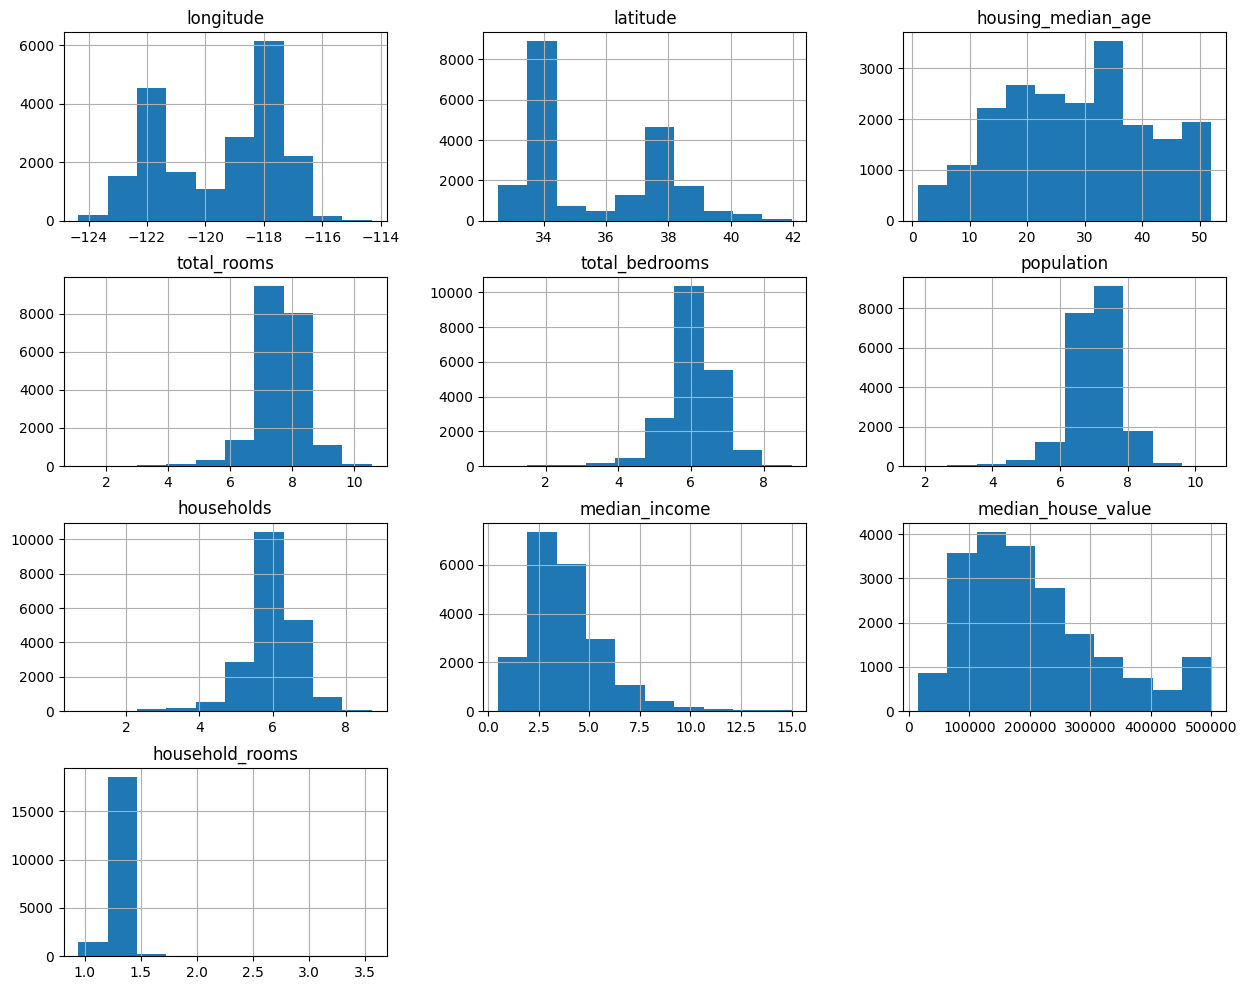

In [13]:
df.hist(figsize=(15,12))

Identifing skewed data lead to biased predictions at ("total_rooms", "total_bedrooms", "population", "households") which need a Log Transformation.

# Heatmap
Exploring correlations between numeric features only (Heatmap can't handle categorical features)

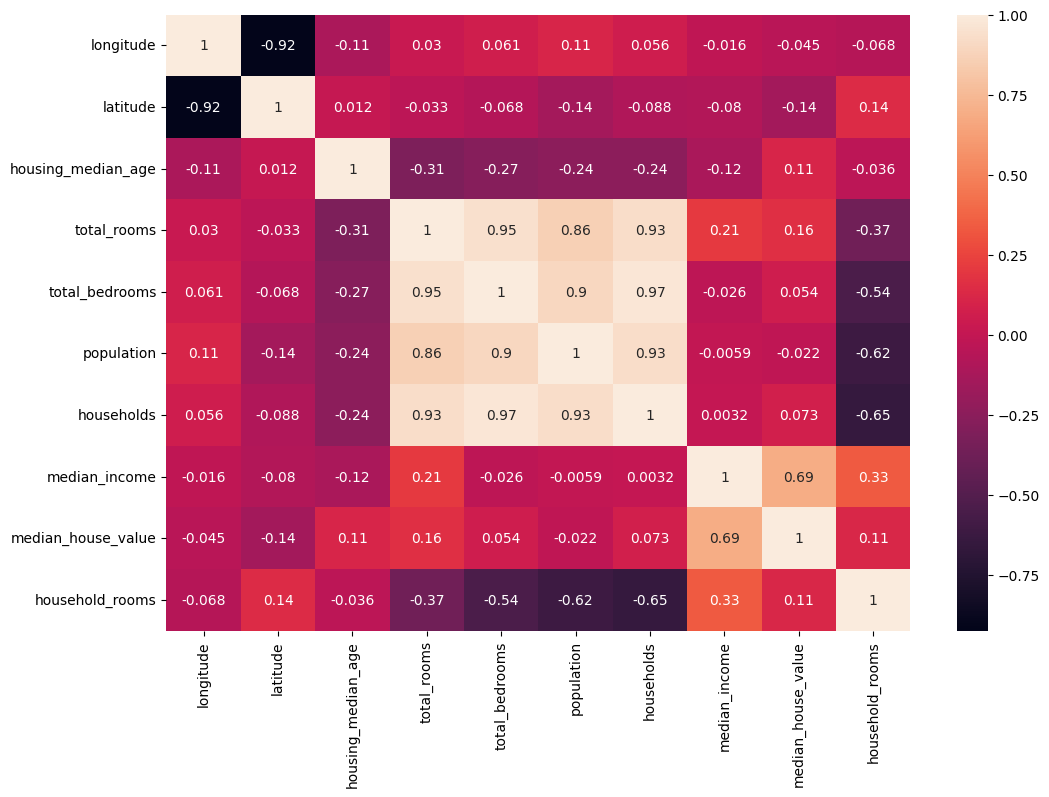

In [14]:
numerical_df = df.select_dtypes(include=['float64'])

plt.figure(figsize=(12, 8))
sns.heatmap(numerical_df.corr(),annot=True)

plt.show()

Based on the Heatmap above:
- "median_income" is the most effective feature on the "median_house_value" (house price) with corr = 0.69
- features like "total_rooms" or "population" show weak correlations with "median_house_value", but that doesn't mean that we can't use them (A feature might be weak on its own but powerful when combined with another).
- To create more meaningful predictors, we will derive ("total_rooms" / "households") but why?
If the model sees a "total_rooms" value of 5000 in a given area, it won't know if this area have 500 houses, each with 10 rooms or if this area have 2500 houses, each with only 2 rooms.
The number "5000" alone is misleading, but dividing by the number of households (number of families/houses) immediately solves this puzzle and reveals number of houses to the model.
---
When you divide total_rooms by households:
- If the result is large (e.g., 7 or 8): The model will immediately understand that the houses are large and spacious, and therefore associate this with a high price.
- If the result is small (e.g., 2 or 3): The model will understand that the houses are small (often apartments), and therefore predict a lower price.

# Boxplot
Exploring the correlation between "ocean_proximity" (categorical feature) & "median_house_value" (house price)

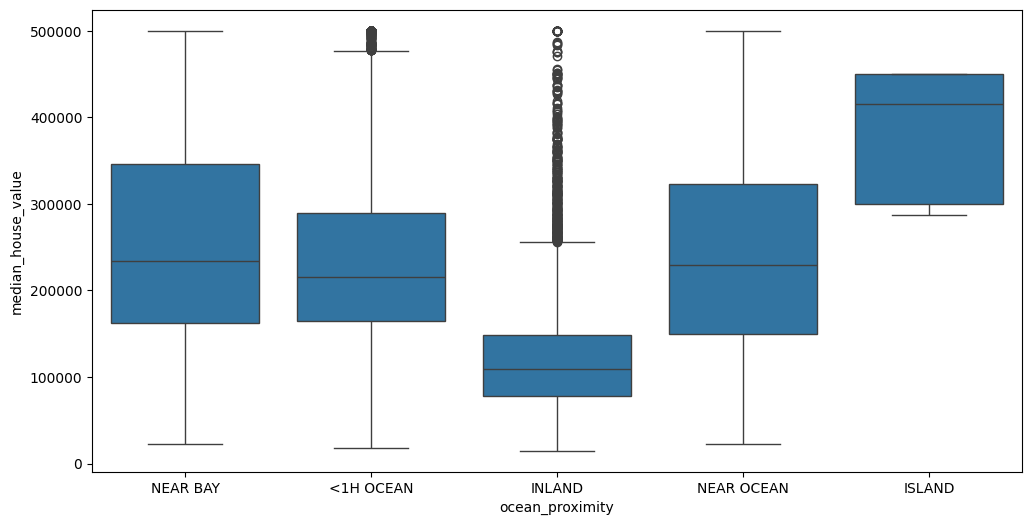

In [15]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='ocean_proximity', y='median_house_value')

plt.show()

Based on the Boxplot analysis above:
- There is a clear difference in price distribution based on geographical location, which means there is a strong relation between them.
- There is a visible price ceiling at $500,000, suggesting that the data might be capped there.
- A high density of outliers (Couldn't be errors) is visible in the <1H OCEAN and INLAND categories will be addressed (If we decide to) after the data splitting (to avoid avoid Data Leakage) ensuring a Real-World Test that will evaluates how the model performs against unexpected data